# CAMM Hackathon #10: STEM Image Restoration

STEM image credits: Austin Houston


In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import json

In [ ]:
!gdown --id 14N5Vg7Baqj2OdvgTD1l9oaWWvNvPCpYs --fuzzy
!gdown --id 1IB2Au4Dh7iNZCeOmj1dmaGB2JOIFAxoN --fuzzy

In [6]:
#@title h5 load
def save_dict_to_hdf5(file_path, data_dict):
    with h5py.File(file_path, 'w') as f:
        _recursively_save(f, data_dict)

def _recursively_save(group, data):
    if isinstance(data, dict):
        for key, value in data.items():
            subgroup = group.create_group(str(key))
            _recursively_save(subgroup, value)

    elif isinstance(data, list):
        # Turn list into group with numerical keys
        for i, item in enumerate(data):
            subgroup = group.create_group(str(i))
            _recursively_save(subgroup, item)

    elif isinstance(data, np.ndarray):
        if data.dtype == object:
            # convert each element to string (json)
            data_as_str = np.array([json.dumps(x) for x in data], dtype='S256')
            group.create_dataset('value', data=data_as_str)
        else:
            group.create_dataset('value', data=data)

    elif isinstance(data, (int, float, np.int_, np.float_)):
        group.create_dataset('value', data=data)

    elif data is None:
        group.attrs['value'] = 'None'

    else:
        # Fallback: convert unknown object to JSON string
        group.create_dataset('value', data=json.dumps(data))


def load_hdf5_to_dict(file_path):
    with h5py.File(file_path, "r") as f:
        return _load_item(f)



def _load_item(obj):
    """
    Load any HDF5 object (Group or Dataset) and reconstruct Python object.
    """
    # ---------------------------------------------------------
    # CASE 1 — HDF5 GROUP  (recursive dict or list)
    # ---------------------------------------------------------
    if isinstance(obj, h5py.Group):
        keys = list(obj.keys())

        # Empty group → return None or empty dict
        if len(keys) == 0 and "value" not in obj.attrs:
            return {}

        # Detect list: all keys are integers
        if all(k.isdigit() for k in keys):
            lst = []
            for k in sorted(keys, key=lambda x: int(x)):
                lst.append(_load_item(obj[k]))
            return lst

        # Regular dictionary
        out = {}
        for k in keys:
            out[k] = _load_item(obj[k])

        # Special case: group representing None
        if "value" in obj.attrs and obj.attrs["value"] == "None":
            return None

        return out

    # ---------------------------------------------------------
    # CASE 2 — HDF5 DATASET  (arrays / scalars / strings)
    # ---------------------------------------------------------
    elif isinstance(obj, h5py.Dataset):
        data = obj[()]

        # Scalar
        if np.isscalar(data):
            return data

        # Byte strings → JSON or text
        if isinstance(data, (bytes, np.bytes_)):
            try:
                return json.loads(data.decode())
            except:
                return data.decode()

        # Array of byte strings
        if data.dtype.kind == "S":
            try:
                return [json.loads(x.decode()) for x in data]
            except:
                return [x.decode() for x in data]

        # Normal numpy array
        return data

    # ---------------------------------------------------------
    # CASE 3 — Attributes marking None
    # ---------------------------------------------------------
    else:
        raise ValueError("Unknown HDF5 object type:", obj)


def get_arr(runs, key):
    """
    Extract numpy array from runs[key], automatically handling nested {'value': array}.
    """
    val = runs[key]
    if isinstance(val, dict) and "value" in val:
        return np.asarray(val["value"])
    return np.asarray(val)



In [9]:
#@title masking functions
from scipy.ndimage import binary_dilation
from skimage.draw import line as draw_line

def mask_below_line(im, row=None, frac=0.6, above=True):
    """
    Mask all pixels below (or above) a horizontal threshold row.

    Parameters
    ----------
    im : 2D array
    row   : int, absolute row index. Defaults to frac * H.
    frac  : float, fraction of height for the cut if row is None.
    above : bool, if True mask everything above the line instead.

    Returns
    -------
    mask : bool ndarray (H, W)
    """
    H, W = im.shape
    if row is None:
        row = int(frac * H)
    mask = np.zeros((H, W), dtype=bool)
    if above:
        mask[:row, :] = True
    else:
        mask[row:, :] = True
    return mask

def mask_lakes(im, n_lakes=10, size_range=(10, 220), aspect_range=(0.5, 4.0),
               roughness=0.8, n_harmonics=34, seed=None):
    """
    Lake regions with ragged / torn borders, arranged in a loose cluster.

    The border is a polar curve whose radius is modulated by a sum of random
    sinusoids, producing irregular, non-repeating jagged edges.

    Parameters
    ----------
    im : 2D array
    n_lakes      : number of lakes
    size_range   : (min, max) semi-major axis in pixels
    aspect_range : (min, max) aspect ratio (semi-major / semi-minor)
    roughness    : 0 = smooth ellipse, 1 = very jagged (good range: 0.2–0.6)
    n_harmonics  : number of sinusoidal harmonics added to the border
    seed         : RNG seed

    Returns
    -------
    mask : bool ndarray (H, W)
    """
    rng = np.random.default_rng(seed)
    H, W = im.shape
    mask = np.zeros((H, W), dtype=bool)

    # loose cluster centre
    cy_c = rng.integers(H // 4, 3 * H // 4)
    cx_c = rng.integers(W // 4, 3 * W // 4)
    spread = max(H, W) // 4

    yy, xx = np.mgrid[:H, :W]

    for _ in range(n_lakes):
        cy = int(np.clip(rng.normal(cy_c, spread), 0, H - 1))
        cx = int(np.clip(rng.normal(cx_c, spread), 0, W - 1))
        a = rng.integers(*size_range)           # semi-major
        aspect = rng.uniform(*aspect_range)
        b = max(1, int(a / aspect))             # semi-minor
        angle = rng.uniform(0, np.pi)

        # rotate coordinates
        dy = yy - cy
        dx = xx - cx
        cos_a, sin_a = np.cos(angle), np.sin(angle)
        u = cos_a * dx + sin_a * dy             # along major axis
        v = -sin_a * dx + cos_a * dy            # along minor axis

        # polar angle of every pixel relative to lake centre
        theta = np.arctan2(v, u)

        # ragged radius envelope: 1 + sum of random harmonics
        freqs = rng.integers(2, n_harmonics + 2, size=n_harmonics)
        amps  = rng.uniform(0, roughness / n_harmonics, size=n_harmonics)
        phases = rng.uniform(0, 2 * np.pi, size=n_harmonics)
        envelope = 1.0 + sum(
            amp * np.sin(freq * theta + phase)
            for amp, freq, phase in zip(amps, freqs, phases)
        )

        # pixel is inside if its normalised ellipse distance < ragged envelope
        dist = np.sqrt((u / a) ** 2 + (v / b) ** 2)
        mask |= dist <= envelope

    return ~mask

def mask_lines(im, n_lines=80, thickness=4, orientation="horizontal", seed=None):
    """
    Thin random straight lines across the image (horizontal, vertical, or diagonal).

    Parameters
    ----------
    im : 2D array
    n_lines     : number of lines
    thickness   : line width in pixels (via dilation)
    orientation : "horizontal" | "vertical" | "diagonal" | "mixed"
    seed        : RNG seed

    Returns
    -------
    mask : bool ndarray (H, W)
    """
    rng = np.random.default_rng(seed)
    H, W = im.shape
    mask = np.zeros((H, W), dtype=bool)

    orientations = ["horizontal", "vertical", "diagonal"]

    for _ in range(n_lines):
        if orientation == "mixed":
            ort = rng.choice(orientations)
        else:
            ort = orientation

        if ort == "horizontal":
            r = rng.integers(0, H)
            mask[r, :] = True
        elif ort == "vertical":
            c = rng.integers(0, W)
            mask[:, c] = True
        else:  # diagonal
            r0, c0 = rng.integers(0, H), rng.integers(0, W)
            r1, c1 = rng.integers(0, H), rng.integers(0, W)
            rr, cc = draw_line(r0, c0, r1, c1)
            valid = (rr >= 0) & (rr < H) & (cc >= 0) & (cc < W)
            mask[rr[valid], cc[valid]] = True

    if thickness > 1:
        struct = np.ones((thickness, thickness), dtype=bool)
        mask = binary_dilation(mask, structure=struct)

    return ~mask

def mask_small_blobs(im, n_blobs=300, size_range=(1, 24), seed=None):
    """
    Many tiny blobs simulating dead-pixel clusters or dust on the detector.

    Parameters
    ----------
    im      : 2D array
    n_blobs    : number of small blobs
    size_range : (min_r, max_r) radius in pixels
    seed       : RNG seed

    Returns
    -------
    mask : bool ndarray (H, W)
    """
    rng = np.random.default_rng(seed)
    H, W = im.shape
    mask = np.zeros((H, W), dtype=bool)

    yy, xx = np.ogrid[:H, :W]

    for _ in range(n_blobs):
        cy = rng.integers(0, H)
        cx = rng.integers(0, W)
        r = rng.integers(*size_range)
        mask |= (yy - cy) ** 2 + (xx - cx) ** 2 <= r ** 2

    return ~mask

In [13]:
data = load_hdf5_to_dict('graphene_2.h5')
data_more = load_hdf5_to_dict('HAADF_21.h5')

im0 = data['Measurement_000']['Channel_000']['HAADF']['HAADF'][:1000, :1000]
im1 = data['Measurement_001']['Channel_000']['HAADF']['HAADF'][:1000, :1000]
im2 = data['Measurement_001']['Channel_000']['HAADF']['HAADF'][:1000, -1000:]
im3 = data_more['Measurement_000']['Channel_000']['HAADF']['HAADF']

ims = [im0, im1, im2, im3]

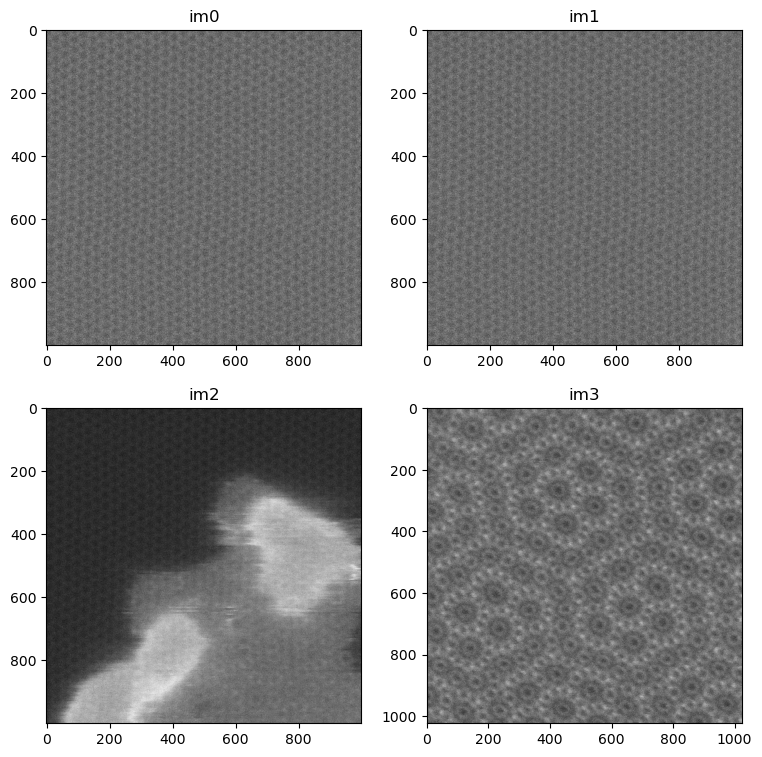

In [14]:
fig, axes = plt.subplots(2,2, figsize=(9,9))

ax = axes.flatten()

for i, _ in enumerate(ax):
  _.imshow(ims[i], cmap='gray')
  _.set_title(f'im{i}')

Text(0.5, 1.0, 'mask_small_blobs()')

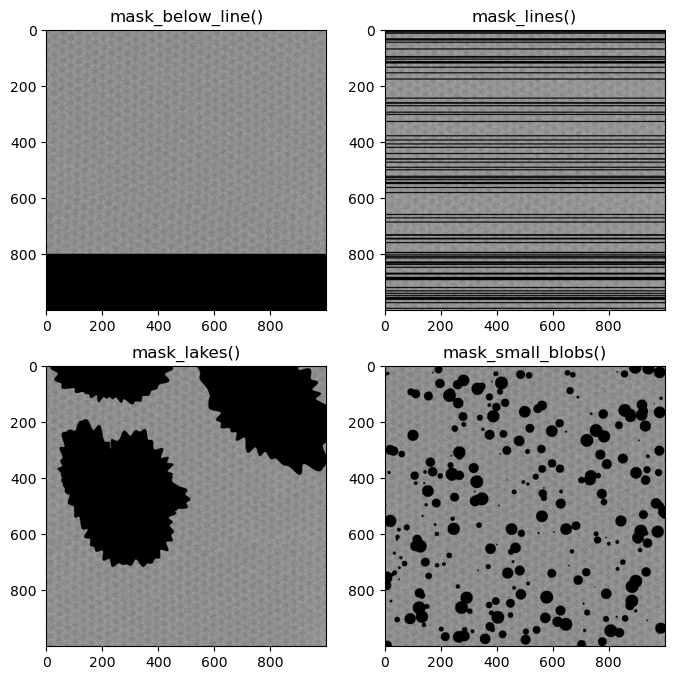

In [15]:
fig, ax = plt.subplots(2,2, figsize=(8,8))


ax[0,0].imshow(mask_below_line(im0, frac=0.8)*im0, cmap='gray')
ax[0,0].set_title('mask_below_line()')

ax[0,1].imshow(mask_lines(im0)*im0, cmap='gray')
ax[0,1].set_title('mask_lines()')

ax[1,0].imshow(mask_lakes(im0)*im0, cmap='gray')
ax[1,0].set_title('mask_lakes()')

ax[1,1].imshow(mask_small_blobs(im0)*im0, cmap='gray')
ax[1,1].set_title('mask_small_blobs()')


# Given a 2D microscopy intensity array and a binary loss mask, reconstruct missing regions and estimate prediction uncertainty

In [377]:
img_0 = mask_below_line(im0, frac=0.8)*im0
img_1 = mask_lines(im3)*im3
img_2 = mask_lakes(im3)*im3
img_3 = mask_small_blobs(im3)*im3

approach 2

In [378]:
import numpy as np
import matplotlib.pyplot as plt

from scipy import ndimage
from scipy.interpolate import griddata
from scipy.optimize import least_squares
from scipy.signal.windows import tukey

from skimage.filters import threshold_otsu
from skimage.feature import peak_local_max

In [379]:
def show_image(img, title="", cmap="gray", figsize=(6,6)):
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.tight_layout()
    plt.show()

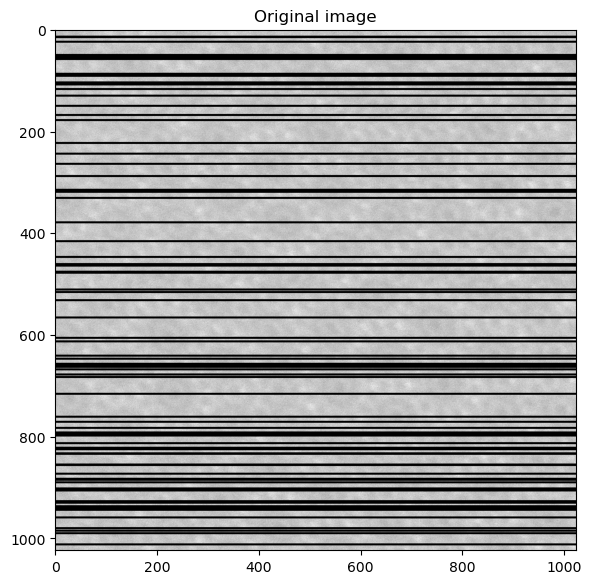

In [381]:
I = img_1
show_image(I, "Original image")

Build the mask automatically from dark regions

In [382]:
def build_mask_from_dark_regions(I, smooth_sigma=1.0):
    I = np.asarray(I, dtype=float)

    I_smooth = ndimage.gaussian_filter(I, sigma=smooth_sigma)
    t = threshold_otsu(I_smooth)

    missing = I_smooth < t
    missing = ndimage.binary_opening(missing, structure=np.ones((2, 2)))
    missing = ndimage.binary_closing(missing, structure=np.ones((3, 3)))
    missing = ndimage.binary_fill_holes(missing)
    # from skimage.morphology import remove_small_objects

    missing = remove_small_objects(missing, min_size=8)

    M = ~missing
    return M, missing, t

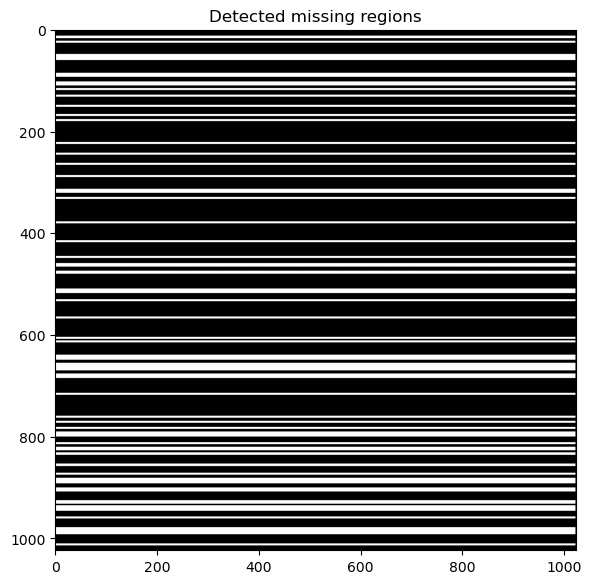

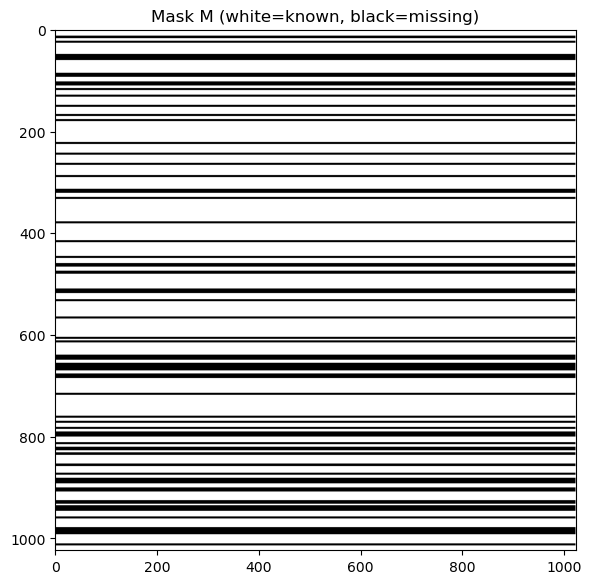

Threshold used: 5962.88313746826


In [383]:
M, missing, t = build_mask_from_dark_regions(I)

show_image(missing.astype(float), "Detected missing regions", cmap="gray")
show_image(M.astype(float), "Mask M (white=known, black=missing)", cmap="gray")
print("Threshold used:", t)

Initial interpolation

In [384]:
def initial_interpolation(I, M, method="linear"):
    I = np.asarray(I, dtype=float)
    M = np.asarray(M, dtype=bool)

    yy, xx = np.indices(I.shape)

    known_points = np.column_stack((yy[M], xx[M]))
    known_values = I[M]
    missing_points = np.column_stack((yy[~M], xx[~M]))

    I_fill = I.copy()

    if len(missing_points) > 0:
        interp_vals = griddata(
            known_points,
            known_values,
            missing_points,
            method=method,
            fill_value=np.nan
        )

        if np.any(np.isnan(interp_vals)):
            interp_vals2 = griddata(
                known_points,
                known_values,
                missing_points[np.isnan(interp_vals)],
                method="nearest"
            )
            interp_vals[np.isnan(interp_vals)] = interp_vals2

        I_fill[~M] = interp_vals

    return I_fill

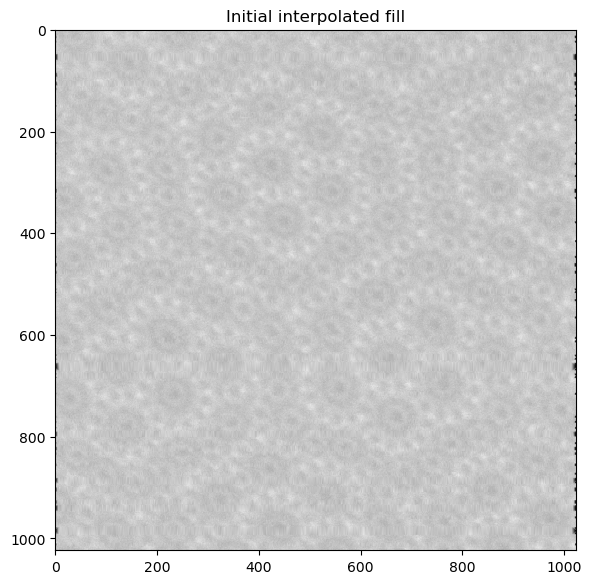

In [385]:
I_fill0 = initial_interpolation(I, M, method="linear")
show_image(I_fill0, "Initial interpolated fill")

Normalize

In [386]:
def normalize_known(I, M):
    I = np.asarray(I, dtype=float)
    M = np.asarray(M, dtype=bool)

    mu = np.mean(I[M])
    sigma = np.std(I[M])

    if sigma < 1e-12:
        return I - mu
    return (I - mu) / sigma

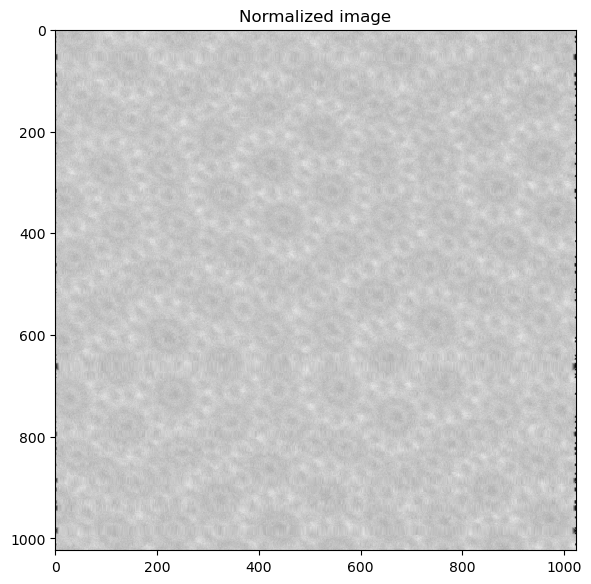

In [387]:
I_norm = normalize_known(I_fill0, M)
show_image(I_norm, "Normalized image")

Pad + soft window before FFT

In [388]:
def apply_window_soft(I, alpha=0.1):
    ny, nx = I.shape
    wx = tukey(nx, alpha=alpha)
    wy = tukey(ny, alpha=alpha)
    W = np.outer(wy, wx)
    return I * W

def pad_reflect(I, pad=128):
    return np.pad(I, ((pad, pad), (pad, pad)), mode='reflect')

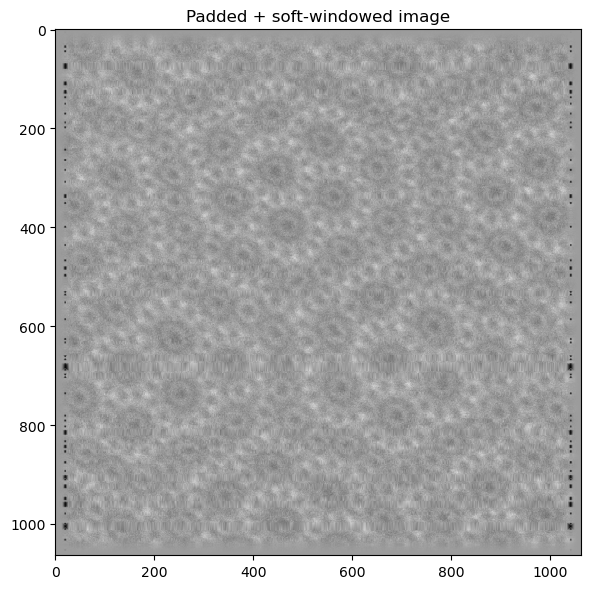

In [389]:
pad = 20
I_pad = pad_reflect(I_norm, pad=pad)
I_prep = apply_window_soft(I_pad, alpha=0.08)

show_image(I_prep, "Padded + soft-windowed image")

FFT

In [390]:
def fft2_image(I):
    F = np.fft.fft2(I)
    F_shift = np.fft.fftshift(F)
    Mag = np.abs(F_shift)
    return F, F_shift, Mag

def fft_log_magnitude(Mag):
    return np.log1p(Mag)

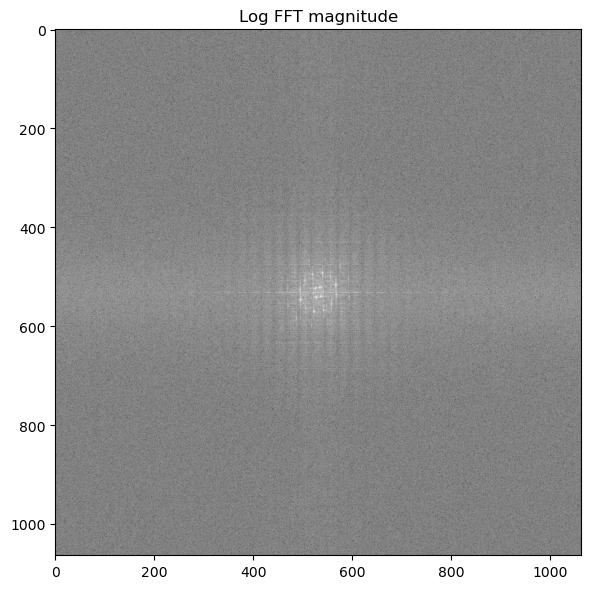

In [391]:
F, F_shift, Mag = fft2_image(I_prep)
show_image(fft_log_magnitude(Mag), "Log FFT magnitude")

Detect reciprocal lattice peaks

In [392]:
def find_bragg_peaks(Mag, min_distance=10, threshold_rel=0.2, exclude_center_radius=20):
    Mag = np.asarray(Mag, dtype=float)
    ny, nx = Mag.shape
    cy, cx = ny // 2, nx // 2

    Mag2 = Mag.copy()
    yy, xx = np.indices(Mag.shape)
    rr = np.sqrt((yy - cy)**2 + (xx - cx)**2)
    Mag2[rr < exclude_center_radius] = 0.0

    peaks = peak_local_max(
        Mag2,
        min_distance=min_distance,
        threshold_rel=threshold_rel
    )
    return peaks

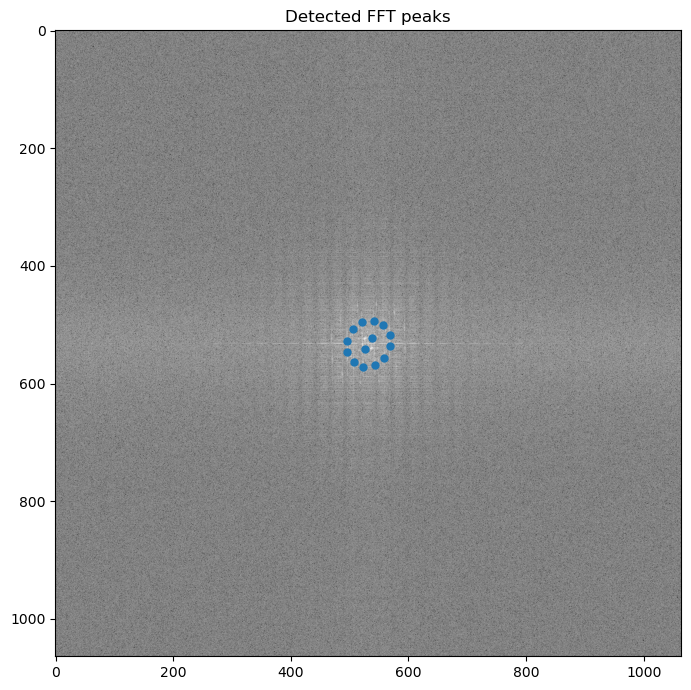

Number of peaks found: 14


In [395]:
peaks = find_bragg_peaks(Mag, min_distance=10, threshold_rel=0.2, exclude_center_radius=10)

plt.figure(figsize=(7,7))
plt.imshow(fft_log_magnitude(Mag), cmap="gray")
if len(peaks) > 0:
    plt.scatter(peaks[:,1], peaks[:,0], s=25)
plt.title("Detected FFT peaks")
plt.tight_layout()
plt.show()

print("Number of peaks found:", len(peaks))

Keep selected peaks only

In [396]:
def keep_selected_peaks_with_dc(F, peaks, radius=5, dc_radius=3):
    F_shift = np.fft.fftshift(F)
    ny, nx = F_shift.shape
    cy, cx = ny // 2, nx // 2

    yy, xx = np.indices(F_shift.shape)
    mask = np.zeros_like(F_shift, dtype=bool)

    for py, px in peaks:
        mask |= ((yy - py)**2 + (xx - px)**2 <= radius**2)

        sy = 2 * cy - py
        sx = 2 * cx - px
        mask |= ((yy - sy)**2 + (xx - sx)**2 <= radius**2)

    mask |= ((yy - cy)**2 + (xx - cx)**2 <= dc_radius**2)

    F_lat_shift = np.zeros_like(F_shift, dtype=complex)
    F_lat_shift[mask] = F_shift[mask]

    return np.fft.ifftshift(F_lat_shift), mask

Visualize

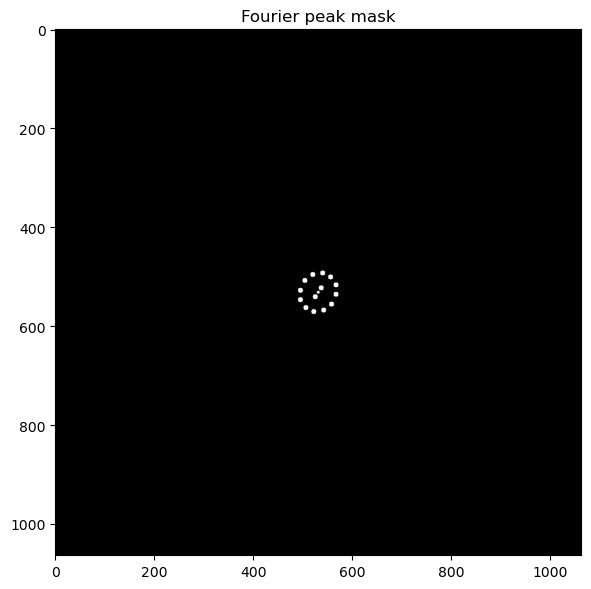

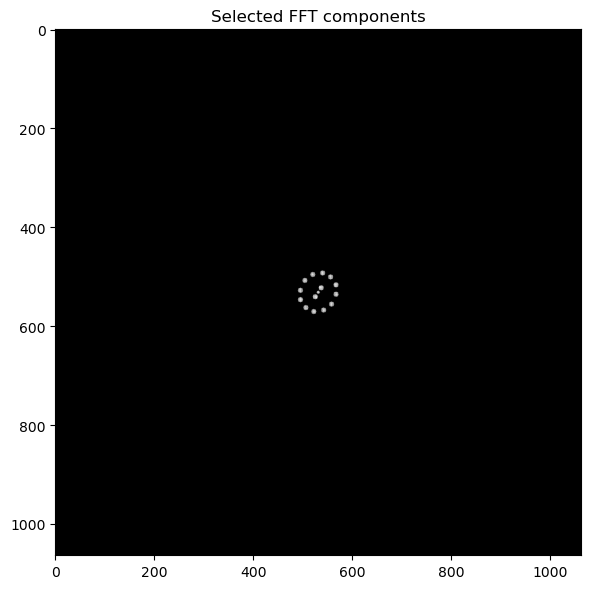

In [397]:
F_lat, Fmask = keep_selected_peaks_with_dc(F, peaks, radius=5, dc_radius=3)

show_image(Fmask.astype(float), "Fourier peak mask", cmap="gray")
show_image(np.log1p(np.abs(np.fft.fftshift(F_lat))), "Selected FFT components")

Inverse FFT to get lattice-only image

In [398]:
def reconstruct_lattice(F_lat):
    return np.fft.ifft2(F_lat).real

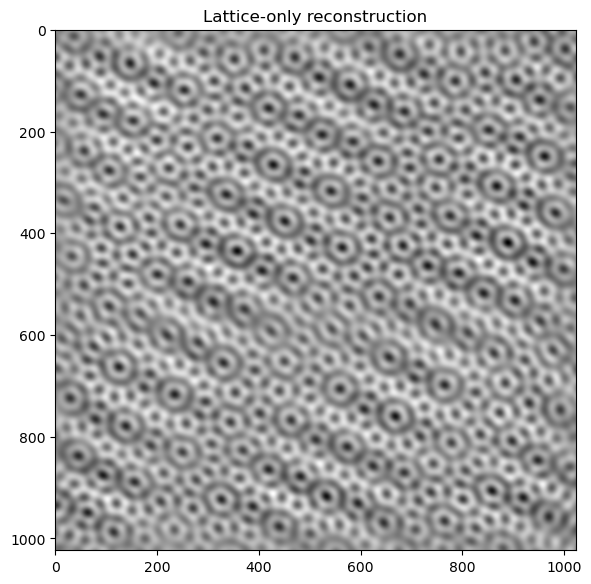

In [399]:
I_lat_pad = reconstruct_lattice(F_lat)
I_lat = I_lat_pad[pad:-pad, pad:-pad]

show_image(I_lat, "Lattice-only reconstruction")

Fit lattice model to known pixels

In [400]:
def fit_model_to_known_pixels(I_lat, I, M):
    I_lat = np.asarray(I_lat, dtype=float)
    I = np.asarray(I, dtype=float)
    M = np.asarray(M, dtype=bool)

    def residuals(params):
        dy, dx, a, b = params
        shifted = ndimage.shift(I_lat, shift=(dy, dx), order=3, mode='nearest')
        model = a * shifted + b
        return (model[M] - I[M]).ravel()

    p0 = [0.0, 0.0, 1.0, 0.0]
    result = least_squares(residuals, p0)
    return result.x

def apply_fit(I_lat, theta):
    dy, dx, a, b = theta
    shifted = ndimage.shift(I_lat, shift=(dy, dx), order=3, mode='nearest')
    return a * shifted + b

theta = [dy, dx, a, b] = [-1.42222305e-02 -3.40388082e-04  8.03245721e+02  1.28470634e+04]


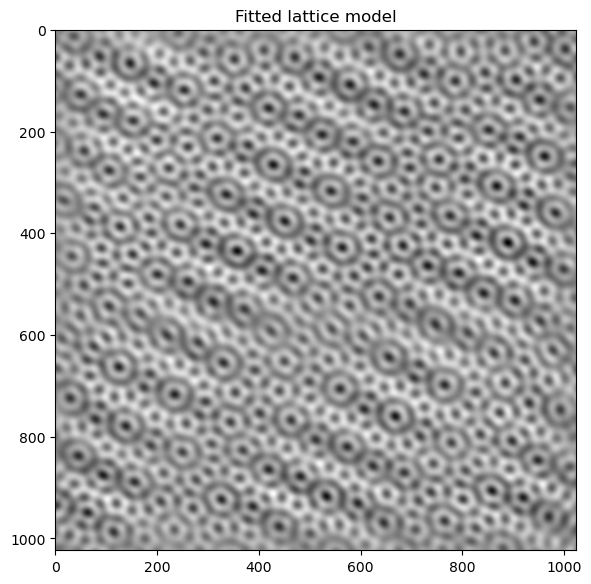

In [401]:
theta = fit_model_to_known_pixels(I_lat, I, M)
I_model = apply_fit(I_lat, theta)

print("theta = [dy, dx, a, b] =", theta)
show_image(I_model, "Fitted lattice model")

Fill only the missing region

In [402]:
def fill_missing_with_model(I, M, I_model):
    I_fill = I.copy()
    I_fill[~M] = I_model[~M]
    return I_fill

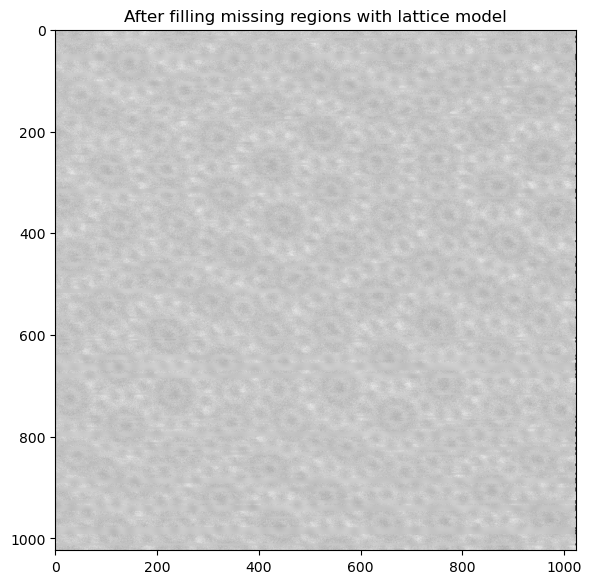

In [403]:
I_fill1 = fill_missing_with_model(I, M, I_model)
show_image(I_fill1, "After filling missing regions with lattice model")

Residual refinement

In [404]:
def refine_residual(I_fill, I, M, sigma=1.0):
    I_fill = np.asarray(I_fill, dtype=np.float64)
    I = np.asarray(I, dtype=np.float64)
    M = np.asarray(M, dtype=bool)

    residual = np.zeros_like(I_fill, dtype=np.float64)
    residual[M] = I[M] - I_fill[M]

    residual_smooth = ndimage.gaussian_filter(residual, sigma=sigma).astype(np.float64)
    weight = ndimage.gaussian_filter(M.astype(np.float64), sigma=sigma)
    weight = np.maximum(weight, 1e-8)

    residual_smooth = residual_smooth / weight

    I_refined = I_fill.copy()
    I_refined[~M] += residual_smooth[~M]

    # keep measured pixels exact
    I_refined[M] = I[M]

    return I_refined

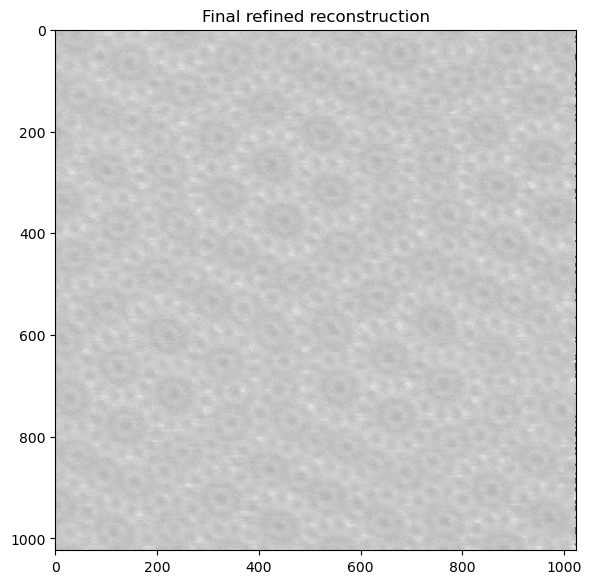

In [405]:
I_final = refine_residual(I_fill1, I, M, sigma=1.0)
show_image(I_final, "Final refined reconstruction")

resutls

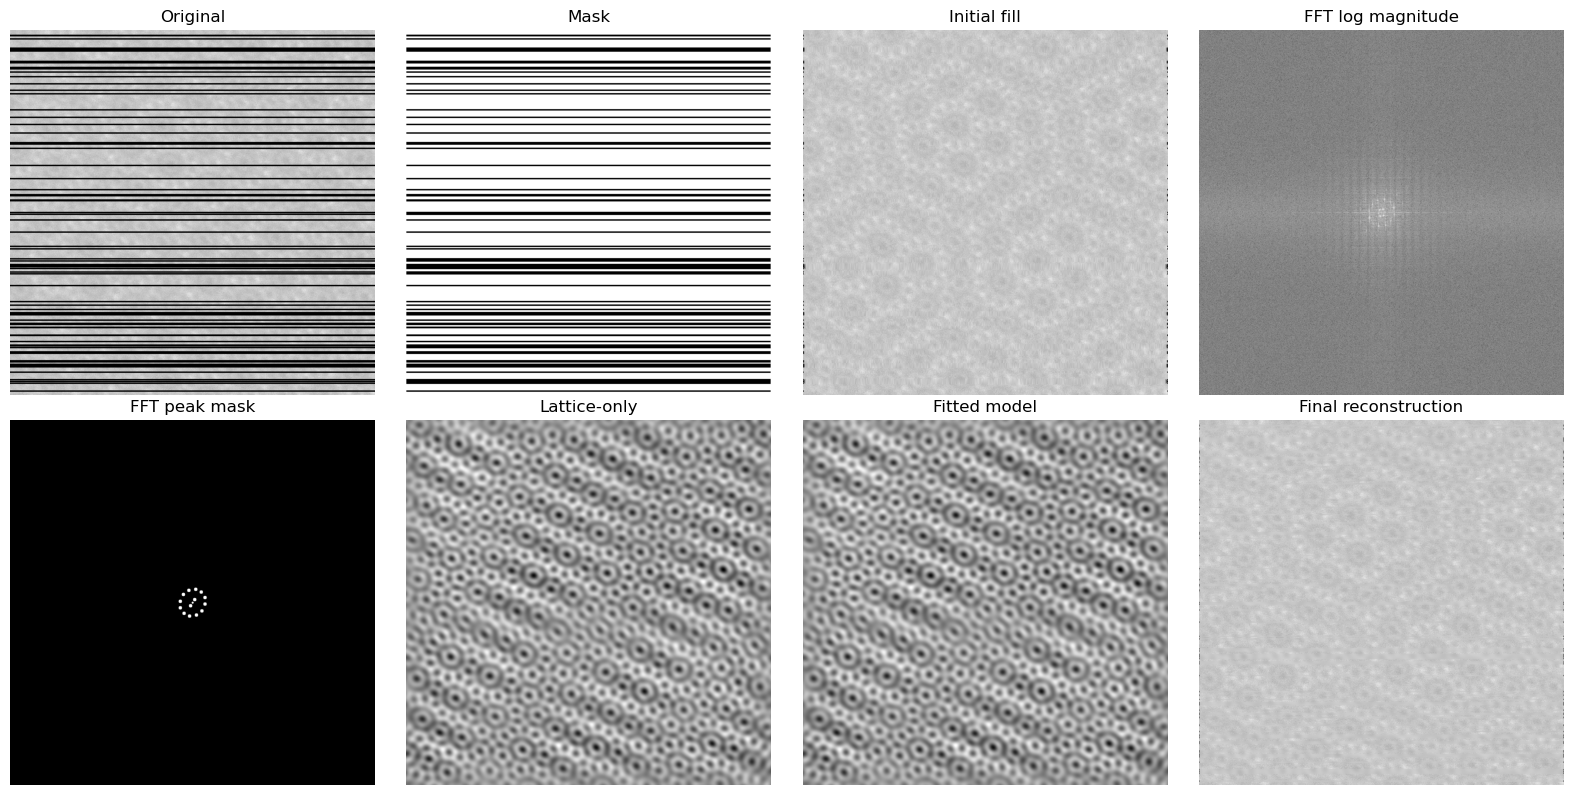

In [406]:
fig, ax = plt.subplots(2, 4, figsize=(16, 8))

ax[0,0].imshow(I, cmap="gray")
ax[0,0].set_title("Original")

ax[0,1].imshow(M, cmap="gray")
ax[0,1].set_title("Mask")

ax[0,2].imshow(I_fill0, cmap="gray")
ax[0,2].set_title("Initial fill")

ax[0,3].imshow(np.log1p(Mag), cmap="gray")
ax[0,3].set_title("FFT log magnitude")

ax[1,0].imshow(Fmask, cmap="gray")
ax[1,0].set_title("FFT peak mask")

ax[1,1].imshow(I_lat, cmap="gray")
ax[1,1].set_title("Lattice-only")

ax[1,2].imshow(I_model, cmap="gray")
ax[1,2].set_title("Fitted model")

ax[1,3].imshow(I_final, cmap="gray")
ax[1,3].set_title("Final reconstruction")

for a in ax.ravel():
    a.axis("off")

plt.tight_layout()
plt.show()

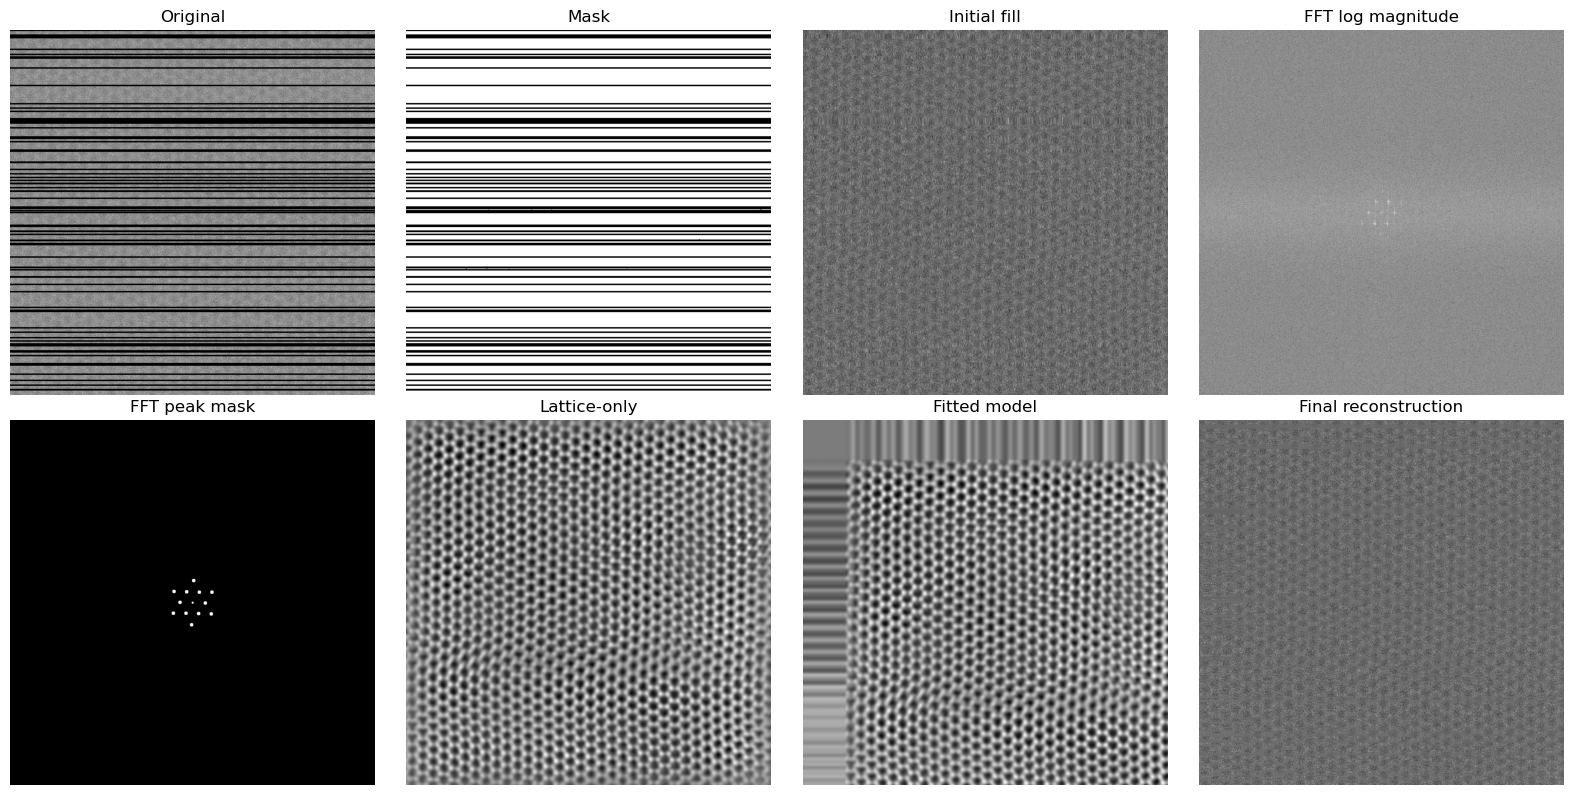

In [216]:
fig, ax = plt.subplots(2, 4, figsize=(16, 8))

ax[0,0].imshow(I, cmap="gray")
ax[0,0].set_title("Original")

ax[0,1].imshow(M, cmap="gray")
ax[0,1].set_title("Mask")

ax[0,2].imshow(I_fill0, cmap="gray")
ax[0,2].set_title("Initial fill")

ax[0,3].imshow(np.log1p(Mag), cmap="gray")
ax[0,3].set_title("FFT log magnitude")

ax[1,0].imshow(Fmask, cmap="gray")
ax[1,0].set_title("FFT peak mask")

ax[1,1].imshow(I_lat, cmap="gray")
ax[1,1].set_title("Lattice-only")

ax[1,2].imshow(I_model, cmap="gray")
ax[1,2].set_title("Fitted model")

ax[1,3].imshow(I_final, cmap="gray")
ax[1,3].set_title("Final reconstruction")

for a in ax.ravel():
    a.axis("off")

plt.tight_layout()
plt.show()

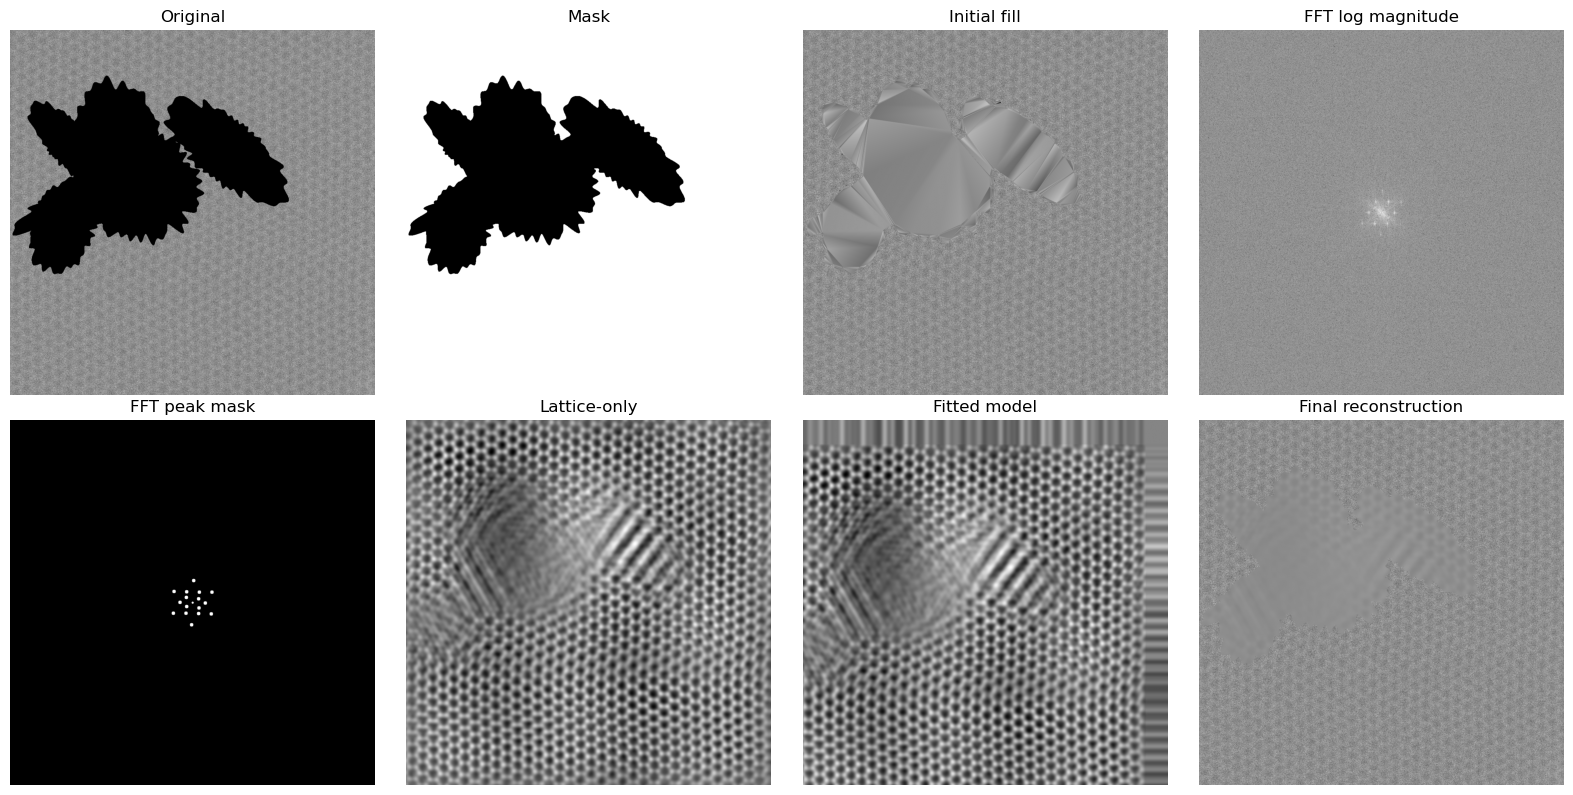

In [273]:
fig, ax = plt.subplots(2, 4, figsize=(16, 8))

ax[0,0].imshow(I, cmap="gray")
ax[0,0].set_title("Original")

ax[0,1].imshow(M, cmap="gray")
ax[0,1].set_title("Mask")

ax[0,2].imshow(I_fill0, cmap="gray")
ax[0,2].set_title("Initial fill")

ax[0,3].imshow(np.log1p(Mag), cmap="gray")
ax[0,3].set_title("FFT log magnitude")

ax[1,0].imshow(Fmask, cmap="gray")
ax[1,0].set_title("FFT peak mask")

ax[1,1].imshow(I_lat, cmap="gray")
ax[1,1].set_title("Lattice-only")

ax[1,2].imshow(I_model, cmap="gray")
ax[1,2].set_title("Fitted model")

ax[1,3].imshow(I_final, cmap="gray")
ax[1,3].set_title("Final reconstruction")

for a in ax.ravel():
    a.axis("off")

plt.tight_layout()
plt.show()